In [2]:
%load_ext autoreload
%autoreload 2

### Eval Losses

plot training and validation losses from training

In [6]:
import matplotlib.pyplot as plt
import json, os

In [ ]:
def load_loss(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

holders = [None, None, None, None]
for ver in range(1, 5):
    file_path = f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{ver}/train_val_loss.json"
    holders[ver - 1] = load_loss(file_path)

In [9]:
print(holders[0])
print(holders[0][list(holders[0].keys())[0]]['train'])

{'2026-03-11 15:06:18.525066': {'train': [2.8770269538132345, 1.8838271443744956, 1.5549065049992687, 1.3912784257811244, 1.2914645744992728, 1.224300738799202, 1.1752327157227882, 1.1380607543450025, 1.1088607398917296, 1.0857832914357106, 1.0669770764533268, 1.050890436312795, 1.0373039314677153, 1.0268014755830595, 1.0163213376305638, 1.0088491439977854, 1.0011423333853366, 0.9933619015213343, 0.9880495984402269, 0.9833286508091054], 'val': [2.1334681744073674, 1.6449633803441568, 1.4440909831150754, 1.3396879663173917, 1.2726755673184051, 1.2147943880300929, 1.1709242878664363, 1.1412088025329414, 1.1239901811691992, 1.0966029177637486, 1.0863982474808098, 1.0845998241655515, 1.0777197408448516, 1.0632675102012823, 1.0590704953445353, 1.048879744588528, 1.034856637163229, 1.034746686677594, 1.0340723300487737, 1.02573963370841]}}
[2.8770269538132345, 1.8838271443744956, 1.5549065049992687, 1.3912784257811244, 1.2914645744992728, 1.224300738799202, 1.1752327157227882, 1.138060754345

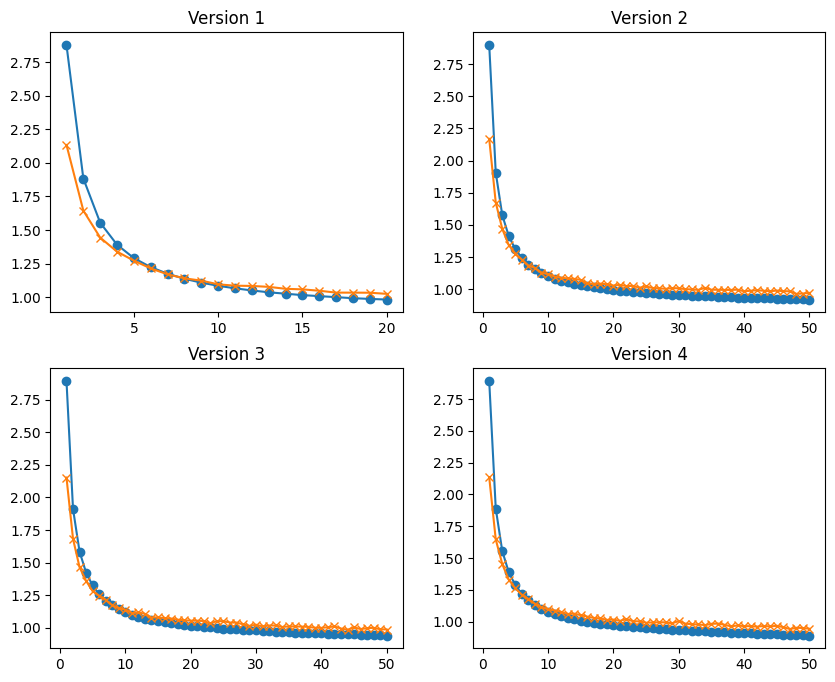

In [15]:
epochs = range(1, len(holders[0][list(holders[0].keys())[0]]['train']) + 1)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

def set_ax(ax, version, loss):
    epochs = range(1, len(loss[list(loss.keys())[0]]['train']) + 1)
    ax.set_title(f'Version {version}')
    ax.plot(epochs, loss[list(loss.keys())[0]]['train'], label='Training loss', marker='o')
    # Plot validation loss
    ax.plot(epochs, loss[list(loss.keys())[0]]['val'], label='Validation loss', marker='x')

set_ax(axs[0, 0], 1, holders[0])
set_ax(axs[0, 1], 2, holders[1])
set_ax(axs[1, 0], 3, holders[2])
set_ax(axs[1, 1], 4, holders[3])

plt.show()

In [17]:
loss_range = []
for holder in holders:
    tloss = holder[list(holder.keys())[0]]['train']
    diff = max(tloss) - min(tloss)
    print(f"{max(tloss)} - {min(tloss)} --> {diff}")
    loss_range.append(diff)

2.8770269538132345 - 0.9833286508091054 --> 1.893698303004129
2.898617761533011 - 0.9193038401129471 --> 1.9793139214200641
2.8946523597933655 - 0.9397208977410748 --> 1.9549314620522908
2.8918259175704724 - 0.889604765156093 --> 2.0022211524143794


In [1]:
## quickly check the storage mode of subcell embeddings
import torch 

data = torch.load('/scratch/users/samutiti/U54/embeddings/all_harmonized_features_microscope_vit.pth', weights_only=False)

In [3]:
print(type(data))
print(type(data[0]))
print(type(data[1]))

<class 'tuple'>
<class 'pandas.DataFrame'>
<class 'torch.Tensor'>


In [5]:
print(data[1].shape)

torch.Size([1138378, 1536])


### Eval inference outputs

evaluate embeddings / set up for PCA and Umapping

In [5]:
!pip install scanpy

  Obtaining dependency information for scanpy from https://files.pythonhosted.org/packages/44/f0/000ac705a3d5b8744c6eabfce6b413b131829542ffec05020b1e931ffed4/scanpy-1.12-py3-none-any.whl.metadata
  Using cached scanpy-1.12-py3-none-any.whl.metadata (8.4 kB)
  Obtaining dependency information for fast-array-utils[accel,sparse]>=1.2.1 from https://files.pythonhosted.org/packages/5f/cb/ddcf4ad63ba88df95025837e35faf6ea6862bab1327f836801ba02140a22/fast_array_utils-1.3.1-py3-none-any.whl.metadata
  Using cached fast_array_utils-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Obtaining dependency information for numba>=0.60 from https://files.pythonhosted.org/packages/9b/89/1a74ea99b180b7a5587b0301ed1b183a2937c4b4b67f7994689b5d36fc34/numba-0.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Using cached numba-0.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Obtaining dependency information for patsy from https://files.pythonhosted.org/p

In [1]:
import anndata as ad 

training_v = 4
embeddings = ad.read_h5ad(f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{training_v}/inference.h5ad")

In [7]:
print(embeddings)
adata = embeddings

AnnData object with n_obs × n_vars = 1138378 × 1280
    obs: 'cell_id', 'if_plate_id', 'position', 'sample', 'atlas_name', 'antibody', 'ensembl_ids', 'gene_names', 'locations', 'cell_path', 'Time (ms)'


In [ ]:
import scanpy as sc

NUM_PCS = 50
LEI_RES = 0.3

sc.pp.pca(
        adata,
        n_comps=NUM_PCS,
        svd_solver="arpack"
    )
print('pca complete')

sc.pp.neighbors(
        adata,
        n_neighbors=30,
        n_pcs=NUM_PCS,
    )
print('nieghbors complete')

sc.tl.leiden(
        adata,
        resolution=LEI_RES,
        key_added=f'leiden_{LEI_RES}'
    )
print('leiden complete')

sc.tl.umap(
        adata,
        min_dist=0.1,
    )

print('umap complete')

adata.obs["umap_x"] = adata.obsm["X_umap"][:, 0]
adata.obs["umap_y"] = adata.obsm["X_umap"][:, 1]

### Visualize Umap
sc.pl.umap(
        adata,
        color=[f"leiden_{LEI_RES}"],
        show=False,
        save=f"_training_V0{training_v}_mlp_embed.png"
    )


pca complete
